# Final Project: Time and Daily Temperature Ranges

This Jupyter notebook analyzes the daily temperature ranges and their trends over time. Each year is sampled weekly, noting the average and standard deviation of temperature ranges for each country from 1950 to 2026.

### Step 1

The first code cell loads the CMIP6 dataset with OpenVisus into a `DBReader` object. An example read is made to test the user's environment.

In [1]:
import numpy as np
import OpenVisus as ov
from datetime import datetime
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pyspark import SparkContext
import math
import geopandas as gpd
from unidecode import unidecode
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import time
from datetime import datetime, timedelta
from utils import CountryFinder
import os

class DBReader:
    def __init__(self):
        self.__db = ov.LoadDataset(
            "http://atlantis.sci.utah.edu/mod_visus?dataset=nex-gddp-cmip6"
        )
        self.__model     = "ACCESS-CM2"
        self.__scenario  = "historical"
        
        '''
        tasmax
        Daily Maximum Near-Surface Air Temperature
        Degrees Kelvin
        
        tasmin
        Daily Minimum Near-Surface Air Temperature
        Degrees Kelvin
        '''

    def __calculate_day_of_year(self, date_str):
        date = datetime.strptime(date_str, '%Y-%m-%d')
        start_of_year = datetime(date.year, 1, 1)
        day_of_year = (date - start_of_year).days   
        return day_of_year
        
    def __get_timestep(self, date_str):
        date = datetime.strptime(date_str, '%Y-%m-%d')
        day_of_year = self.__calculate_day_of_year(date_str)
        total_days = 365 + (1 if (date.year % 4 == 0 and date.year % 100 != 0) or (date.year % 400 == 0) else 0)
        return f"{date.year*total_days+day_of_year}"
        
    def __read_raw(self, timestamp, domax):
        timestep_index = int(self.__get_timestep(timestamp))
        return self.__db.read(
            time = timestep_index,
            quality = 0,
            field = f"{"tasmax" if domax else "tasmin"}_day_{self.__model}_{self.__scenario}_r1i1p1f1_gn"
        )

    def read_diff(self, timestamp):
        return self.__read_raw(timestamp, True) - self.__read_raw(timestamp, False)

dbr = DBReader()
ex_temp_ranges = dbr.read_diff('1950-01-01')
print(ex_temp_ranges.shape)

(600, 1440)


### Step 2

The second code cell uses the precomputed country matrix. Each longitude-latitude pair for an `np.ndarray` with shape `(600, 1440)` is assigned a country ID. This cell, although one line, confirms whether the user has the binary file.

In [2]:
country_matrix = np.fromfile("mapdata/cmat.bin").reshape((600, 1440)).astype(np.int32)

### Step 3

The third cell defines a function for displaying any `np.ndarray`'s with shape `(600, 1440)`. The previous two arrays are displayed here for further confirmation.

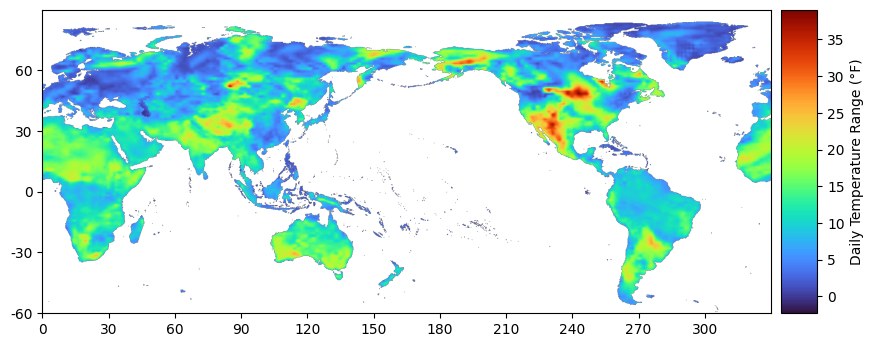

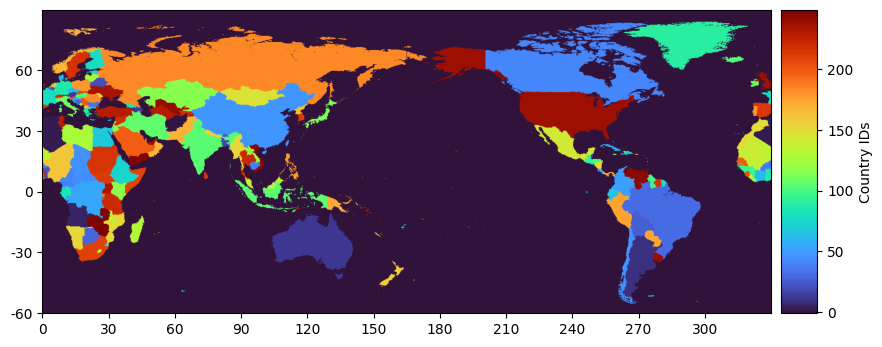

In [3]:
def show_map(data: np.ndarray, title: str):
    y_max, x_max = data.shape
    xlabels = [str(x) for x in range(0, 360, 30)]
    ylabels = [str(y) for y in range(-60, 91, 30)]
    xticks = np.linspace(0, x_max, len(xlabels))
    yticks = np.linspace(0, y_max, len(ylabels))
    
    # Create the plot
    fig, axes = plt.subplots(1, 1,figsize=(10, 8))
    axes.set_xticks(xticks)
    axes.set_xticklabels(xlabels)
    axes.set_yticks(yticks)
    axes.set_yticklabels(ylabels)
    
    # Plot the data
    im = axes.imshow(data[:, :], origin='lower', cmap='turbo')
    
    divider = make_axes_locatable(axes)
    cax = divider.append_axes("right", size="5%", pad=0.1)  # Adjust size and pad as needed
    
    # Add the colorbar
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label(title)
    
    # Show the plot
    plt.show()

show_map(ex_temp_ranges, 'Daily Temperature Range (°F)')
show_map(country_matrix, 'Country IDs')

### Step 4

The following cell defines a function for computing the statistics from each country.

In [4]:
def country_stats(temp_ranges, country_matrix):
    stats = np.zeros((250, 2))
    for i in range(600):
        for j in range(1440):
            cid = country_matrix[i][j]
            trange = temp_ranges[i][j]
            if not np.isnan(trange) and cid != -1:
                stats[cid][0] += 1
                stats[cid][1] += trange
    with np.errstate(divide='ignore', invalid='ignore'):
        output = stats[:,1] / stats[:,0]
        return np.nan_to_num(output, nan=0.0)

ex_country_stats = country_stats(ex_temp_ranges, country_matrix)
print(ex_country_stats[:5])

[12.99285317  5.5810763  14.94200506  1.11279297  9.73422241]


### Step 5

The fifth cell contains a function for graphing the world, where each country has a color depending on its value.

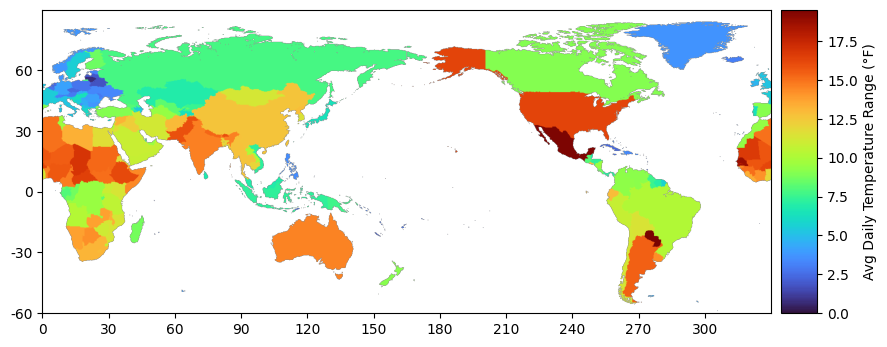

In [5]:
def graph_cstats(stats: np.ndarray, country_matrix: np.ndarray, title: str):
    toplot = np.full(country_matrix.shape, np.nan)
    for i in range(country_matrix.shape[0]):
        for j in range(country_matrix.shape[1]):
            cid = country_matrix[i][j]
            if cid != -1:
                toplot[i][j] = stats[cid]
    show_map(toplot, title)

graph_cstats(ex_country_stats, country_matrix, 'Avg Daily Temperature Range (°F)')

### Step 6

Write function to compute the average daily temperature range for each year, aiming for 20 samples per year.

Time to compute yearly temperature stats: 11.415932 seconds


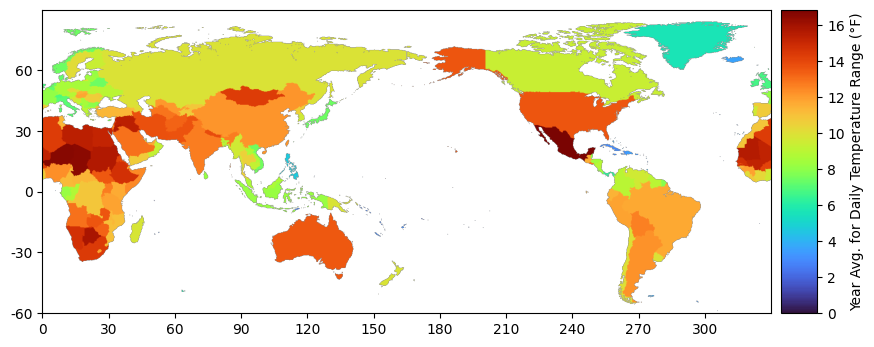

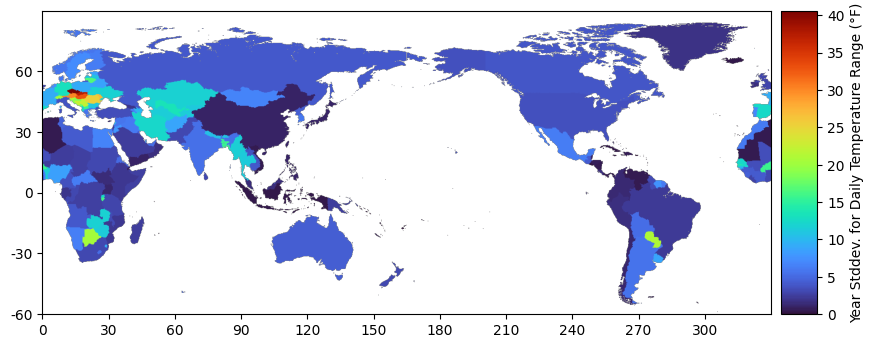

In [6]:
def year_times(year: int, n = 20):
    timestamps = []
    dt = datetime(year=year, month=1, day=1)
    day_step = 365 // n
    for i in range(n):
        timestamps.append(dt.strftime('%Y-%m-%d'))
        dt += timedelta(days=day_step)
    return timestamps

def year_cstats(year: int, n = 20):
    timestamps = year_times(year, n)
    aggs = np.zeros((250, 3))

    # aggregates
    for i in range(len(timestamps)):
        ts = timestamps[i]
        print(f"Processing {ts} ({i/n*100:.1f}%)", end='\r')
        tranges = dbr.read_diff(ts)
        cstats = country_stats(tranges, country_matrix)
        aggs[:,0] += 1
        aggs[:,1] += cstats
        aggs[:,2] += cstats*cstats

    # mean, stddev
    output = np.zeros((250, 2))
    with np.errstate(divide='ignore', invalid='ignore'):
        output[:,0] = aggs[:,1]/aggs[:,0]
        output[:,1] = (aggs[:,2] - (aggs[:,1]*aggs[:,1]) / aggs[:,0]) / aggs[:,0]
    
    return np.nan_to_num(output, nan=0.0)

start = time.perf_counter()
y1_cstats = year_cstats(1950, 5)
end = time.perf_counter()
elapsed = end - start
print(f"Time to compute yearly temperature stats: {elapsed:.6f} seconds")
graph_cstats(y1_cstats[:,0], country_matrix, 'Year Avg. for Daily Temperature Range (°F)')
graph_cstats(y1_cstats[:,1], country_matrix, 'Year Stddev. for Daily Temperature Range (°F)')

### Step 7

With all the helper functions out of the way, now it is time to compute the yearly mean and stddev of temperature ranges for each country.

In [7]:
def years_cstats(years: tuple[int, int], n = 20):
    # index by year, country, mean/stddev
    output = np.zeros((years[1]-years[0]+1, 250, 2))
    year_list = range(years[0], years[1]+1)
    for i in range(len(year_list)):
        output[i] = year_cstats(year_list[i])
    return output

year_tuple = (1950, 2010)
if not os.path.isfile("mapdata/fcstats.bin"):
    final_cstats = years_cstats(year_tuple)
    final_cstats.tofile("mapdata/fcstats.bin")
    print("Saved final country statistics to \"mapdata/fcstats.bin\"")
else:
    print("Loaded final country statistics from \"mapdata/fcstats.bin\"")
    final_cstats = np.fromfile("mapdata/fcstats.bin")
    final_cstats = final_cstats.reshape((year_tuple[1]-year_tuple[0]+1, 250, 2))

Loaded final country statistics from "mapdata/fcstats.bin"


### Step 8

Now that the final country statistics have been computed, data visualization can begin.

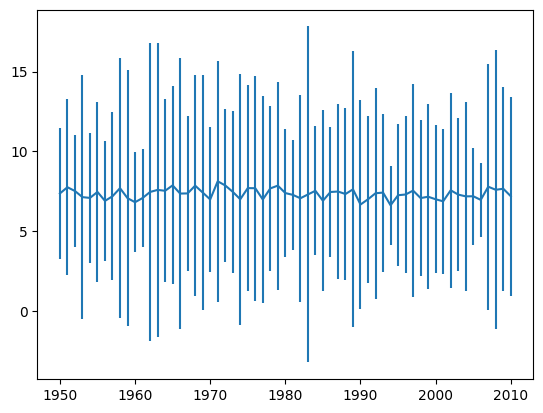

In [8]:
def graph_ranges(country: str, years: tuple[int, int]):
    cf = CountryFinder()
    cid = cf.cid(country)
    year_list = range(years[0], years[1]+1)
    plt.errorbar(year_list, final_cstats[:,cid,0], yerr=final_cstats[:,cid,1]*2)

graph_ranges("Italy", year_tuple)